In [1]:
import os
import operator
from typing import Annotated, Literal
from pydantic import BaseModel
from tavily import TavilyClient
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv
load_dotenv()

/var/folders/50/bxsq6ft917s17qpysvc95xn80000gn/T/ipykernel_34575/3769378289.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

In [2]:

loader = PyPDFLoader("./Documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()

print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [3]:
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")

Split into 51 chunks


In [4]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [5]:
# in-memory only; re-running this cell re-embeds from scratch
vectorstore = Chroma(
    collection_name="rag_tool_use",
    embedding_function=embeddings,
)

vectorstore.add_documents(documents=chunks)

print("Vector store ready")

Vector store ready


In [6]:
llm = ChatOpenAI(model="gpt-5-mini")        # route_question and generate

agent_llm = ChatOpenAI(model="gpt-5-mini")  # agent node; tools bound later

In [7]:
class AgenticRAGState(MessagesState):

    query: str
    retrieved_docs: Annotated[list[Document], operator.add]
    context: Annotated[str, operator.add]
    generation: str
    needs_retrieval: bool

In [8]:
class RouteDecision(BaseModel):

    needs_retrieval: bool

In [9]:
@tool(response_format="content_and_artifact")
def vector_store_search(query: str, k: int = 3):
    """Search the vector store for relevant document passages.
    Adjust k (default 3) to retrieve more or fewer passages."""
    
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    docs = retriever.invoke(query)
    
    context = "\n\n## Vector Store Results\n\n" + "\n\n".join(d.page_content for d in docs)
    
    return context, docs

In [10]:
@tool(response_format="content_and_artifact")
def web_search(query: str, max_results: int = 3):
    """Search the web for current or real-time information.
    Adjust max_results (default 3) to control how many results are returned."""
    
    client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
    response = client.search(query, max_results=max_results)
    
    docs = [
        Document(
            page_content=r["content"],
            metadata={"source": r["url"], "title": r.get("title", "")},
        )
        for r in response["results"]
    ]
    content = "\n\n## Web Search Results\n\n" + "\n\n".join(d.page_content for d in docs)
    return content, docs

In [11]:
tools = [vector_store_search, web_search]

agent_llm_with_tools = agent_llm.bind_tools(tools)

tool_node = ToolNode(tools)

In [12]:
# route_question node — classifies whether the query needs retrieval
def route_question(state: AgenticRAGState) -> dict:

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document or the web, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])

    chain = prompt_template | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({"query": state["query"]})

    return {"needs_retrieval": decision.needs_retrieval}

In [13]:
AGENT_SYSTEM_PROMPT = (
    "You are a retrieval agent with access to two tools:\n\n"
    "1. vector_store_search — use this for questions that can be answered from the internal document: "
    "a technical report titled 'Will EVs Dampen the Oil Price Shock?' covering EV adoption trajectories, "
    "oil demand displacement scenarios, fleet turnover dynamics, battery cost trends, OPEC+ supply behavior, "
    "and energy price volatility projections through 2050. "
    "Use this tool whenever the query references the report, its findings, its projections, or any topic "
    "that would plausibly appear in a domain-specific EV/oil-market research document. "
    "You may increase k beyond the default if broader coverage of the document is needed.\n\n"
    "2. web_search — use this for current or real-time information not covered by the document, such as "
    "recent market data, news, or statistics from 2024 onward. "
    "Always rephrase the query into a concise, keyword-optimized web search string before calling this tool.\n\n"
    "You may call one tool, both tools, or no tool depending on what the query requires. "
    "When both document knowledge and current data are relevant, call both tools."
)

# agent node — decides which tool(s) to call based on the query
def agent(state: AgenticRAGState) -> dict:

    messages = state["messages"]
    if not messages:
        messages = [SystemMessage(content=AGENT_SYSTEM_PROMPT),
                    HumanMessage(content=state["query"])]

    response = agent_llm_with_tools.invoke(messages)

    return {"messages": [response]}

In [14]:
# collect_tool_output node — drains ToolMessages into state fields
def collect_tool_output(state: AgenticRAGState) -> dict:

    tool_messages = [m for m in state["messages"] if isinstance(m, ToolMessage)]
    all_docs, context_parts = [], []

    for msg in tool_messages:
        context_parts.append(msg.content)
        all_docs.extend(msg.artifact)

    return {
        "context": "\n\n".join(context_parts),
        "retrieved_docs": all_docs,
    }

In [15]:
# generate node — produces the final answer with or without retrieved context
def generate(state: AgenticRAGState) -> dict:

    query = state["query"]
    context = state.get("context") or ""

    if context:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"context": context, "query": query})

    else:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"query": query})

    return {"generation": response.content}

In [16]:
def route_after_classification(state: AgenticRAGState) -> Literal["agent", "generate"]:
    return "agent" if state["needs_retrieval"] else "generate"

def route_after_agent(state: AgenticRAGState) -> Literal["tools", "collect_tool_output"]:
    return "tools" if state["messages"][-1].tool_calls else "collect_tool_output"

In [17]:
graph_builder = StateGraph(AgenticRAGState)

graph_builder.add_node("route_question", route_question)
graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("collect_tool_output", collect_tool_output)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "route_question")
graph_builder.add_conditional_edges("route_question", route_after_classification)
graph_builder.add_conditional_edges("agent", route_after_agent)
graph_builder.add_edge("tools", "agent")
graph_builder.add_edge("collect_tool_output", "generate")
graph_builder.add_edge("generate", END)

In [18]:
graph = graph_builder.compile()

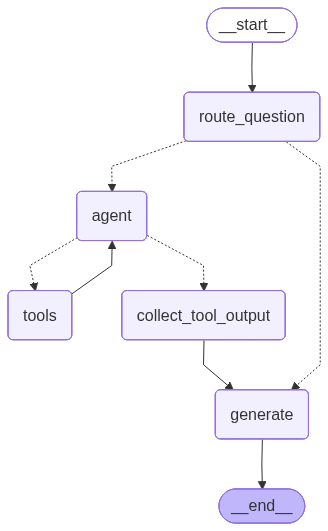

In [19]:
graph

In [20]:
# Case 1: vector store only — domain-specific question about the PDF
query_vs = "According to the report, how will the adoption of electric vehicles impact oil demand?"

result_vs = graph.invoke({"query": query_vs, "messages": [], "retrieved_docs": [], "context": ""})

In [21]:
print("=== CASE 1: Vector Store Only ===")
print(f"needs_retrieval : {result_vs['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_vs.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_vs.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_vs['generation']}")

=== CASE 1: Vector Store Only ===
needs_retrieval : True
retrieved_docs  : 8 docs
context preview : 

## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pi...

Generation:
Summary of the report’s conclusions on EVs and oil demand

- Near term (through 2030): EV adoption will shave meaningful but modest volumes from global oil demand growth — it will tend to delay demand peaks and provide only partial insulation against supply-driven price shocks rather than prevent them.

- Medium to long term (2030–2050): Cumulative fleet electrification could cut oil demand by roughly 20–30 million barrels per day, large enough to materially reshape the oil supply curve and compress price volatility.

- What is displaced: Electrification of passenger and light commercial vehicles primarily reduces gasoline demand; diesel demand (heavy trucks, buses, industry) is much harder to electrify and remains largely intact.

- Timing and geograph

In [22]:
print(result_vs["context"])



## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 8
4. EV Adoption Trajectories and Oil Demand Displacement
 Projecting oil demand displacement from EV adoption requires integrating three distinct
analytical layers: the annual sales trajectory for new EVs, the retirement rate of the existing
ICE fleet, and the average annual mileage and fuel economy of the vehicles being displaced.
The total stock of passenger vehicles globally stands at approximately 1.4 billion, the vast
majority of which are ICE vehicles. With global new vehicle sales of roughly 90 million units
per year and average vehicle lifetimes of 15 to 20 years in developed markets — and often
longer in developing markets — complete fleet electrification cannot occur in less than two to

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 3
Executive Summary
 The global transition towa

In [23]:
# Case 2: web search only — current information not in the PDF
query_web = "What is the current temperature in New Delhi?"

result_web = graph.invoke({"query": query_web, "messages": [], "retrieved_docs": [], "context": ""})

In [24]:
print("=== CASE 2: Web Search Only ===")
print(f"needs_retrieval : {result_web['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_web.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_web.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_web['generation']}")

=== CASE 2: Web Search Only ===
needs_retrieval : True
retrieved_docs  : 19 docs
context preview : 

## Web Search Results

Current New Delhi weather condition is Patchy rain nearby with real-time temperature (34°C - Ho...

Generation:
The current temperature in New Delhi is 34.4°C (93.9°F).


In [25]:
# Case 3: both tools — requires document context AND current web data
query_both = "Compare what the EV report projects for 2030 oil demand and also tell me about the weather in mumbai"

result_both = graph.invoke({"query": query_both, "messages": [], "retrieved_docs": [], "context": ""})

In [26]:
print("=== CASE 3: Both Tools ===")
print(f"needs_retrieval : {result_both['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_both.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_both.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_both['generation']}")

=== CASE 3: Both Tools ===
needs_retrieval : True
retrieved_docs  : 9 docs
context preview : 

## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pi...

Generation:
Short answer
- The EV report does not give a single, explicit numeric projection for global oil demand in 2030. Instead it describes the expected shape and drivers: by 2030 EVs will begin to matter for gasoline demand in advanced economies but will not produce large, immediate global oil-demand reductions — the report expects the strongest dampening of oil‑price shock risk to occur after ~2035 and stresses that effects by 2030 will be limited by slow fleet turnover and persistent diesel demand.

Why (summary of report points relevant to 2030)
- Global passenger-vehicle stock ~1.4 billion and new vehicle sales ≈90 million/yr; average vehicle lifetimes 15–20+ years → full fleet turnover is slow, so rapid global displacement by 2030 is constrained.  
- Battery co

In [27]:
print(result_both["context"])



## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 8
4. EV Adoption Trajectories and Oil Demand Displacement
 Projecting oil demand displacement from EV adoption requires integrating three distinct
analytical layers: the annual sales trajectory for new EVs, the retirement rate of the existing
ICE fleet, and the average annual mileage and fuel economy of the vehicles being displaced.
The total stock of passenger vehicles globally stands at approximately 1.4 billion, the vast
majority of which are ICE vehicles. With global new vehicle sales of roughly 90 million units
per year and average vehicle lifetimes of 15 to 20 years in developed markets — and often
longer in developing markets — complete fleet electrification cannot occur in less than two to

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 3
Executive Summary
 The global transition towa

In [28]:
# Case 4: no retrieval — answerable from general knowledge
query_none = "Explain the difference between kinetic energy and potential energy."

result_none = graph.invoke({"query": query_none, "messages": [], "retrieved_docs": [], "context": ""})

In [29]:
print("=== CASE 4: No Retrieval ===")
print(f"needs_retrieval : {result_none['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_none.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_none.get('context', '') or '(none)'}")
print(f"\nGeneration:\n{result_none['generation']}")

=== CASE 4: No Retrieval ===
needs_retrieval : False
retrieved_docs  : 0 docs
context preview : (none)

Generation:
Kinetic energy and potential energy are two basic forms of mechanical energy, but they come from different physical situations.

- What they are:
  - Kinetic energy (KE) is the energy an object has because of its motion. It increases with speed.
  - Potential energy (PE) is the energy stored in an object because of its position or configuration in a force field (for example gravitational, elastic, or electric).

- Common formulas:
  - KE = 1/2 m v^2 (m = mass, v = speed)
  - Gravitational near Earth: PE = m g h (g = 9.8 m/s^2, h = height above a chosen reference)
  - Elastic (spring): PE = 1/2 k x^2 (k = spring constant, x = displacement)
  - More generally for gravity: U = -G m1 m2 / r

- Key differences:
  - Dependence: KE depends on motion (frame-dependent); PE depends on position/configuration relative to a reference (choice of zero level can be arbitrary).
  - Sign: 

In [30]:
result_both["messages"][0].tool_calls

[{'name': 'vector_store_search',
  'args': {'query': '2030 oil demand projection EVs 2030 oil demand displacement Will EVs Dampen the Oil Price Shock?',
   'k': 6},
  'id': 'call_eBLJ5G7The91d7FMwhGa3TDn',
  'type': 'tool_call'},
 {'name': 'web_search',
  'args': {'query': 'Mumbai current weather', 'max_results': 3},
  'id': 'call_3LGswBRpYwoknJmx1WfXIkGD',
  'type': 'tool_call'}]